# Garda Recorded Crime Statistics

Source: CSO PxStat table **CJQ06 – Recorded Crime Offences**, published by the Central Statistics Office using data from An Garda Siochána's PULSE system.

Quarterly recorded crime incidents by Garda Division and offence type, 2003 Q1 onward. Downloaded directly from the CSO API:
`https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/CJQ06/CSV/1.0/en`

In [1]:
# load the libraries we need and read in the raw crime data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("garda_recorded_crime.csv")
df.head()  # peek at the first 5 rows

,STATISTIC,Statistic Label,TLIST(Q1),Quarter,C02481V03160,Garda Division,C02480V03003,Type of Offence,UNIT,VALUE
0,CJQ06,Recorded crime incidents,20031,2003Q1,11,Cavan/Monaghan Garda Division,01,Homicide & related offences (01),Number,1.0
1,CJQ06,Recorded crime incidents,20031,2003Q1,11,Cavan/Monaghan Garda Division,0111,Murder (0111),Number,0.0
2,CJQ06,Recorded crime incidents,20031,2003Q1,11,Cavan/Monaghan Garda Division,0112,Manslaughter (0112),Number,0.0
3,CJQ06,Recorded crime incidents,20031,2003Q1,11,Cavan/Monaghan Garda Division,0113,Infanticide (0113),Number,0.0
4,CJQ06,Recorded crime incidents,20031,2003Q1,11,Cavan/Monaghan Garda Division,012,Dangerous driving leading to death (012),Number,1.0


## Clean and shape the data

Keep the columns we care about, drop rows with no value recorded, and turn `Quarter` (e.g. `2003Q1`) into a proper year/quarter we can sort and plot by.

In [2]:
# keep only the columns we care about, and rename VALUE to something clearer
crime = df[["Quarter", "Garda Division", "Type of Offence", "VALUE"]].copy()
crime = crime.rename(columns={"VALUE": "Incidents"})
crime = crime.dropna(subset=["Incidents"])  # drop rows with no number recorded

# split "2003Q1" into a Year (2003) and a Quarter number (1)
crime["Year"] = crime["Quarter"].str[:4].astype(int)
crime["Q"] = crime["Quarter"].str[-1].astype(int)

print("Rows after cleaning:", crime.shape[0])
crime.head()

Rows after cleaning: 218456


,Quarter,Garda Division,Type of Offence,Incidents,Year,Q
0,2003Q1,Cavan/Monaghan Garda Division,Homicide & related offences (01),1.0,2003,1
1,2003Q1,Cavan/Monaghan Garda Division,Murder (0111),0.0,2003,1
2,2003Q1,Cavan/Monaghan Garda Division,Manslaughter (0112),0.0,2003,1
3,2003Q1,Cavan/Monaghan Garda Division,Infanticide (0113),0.0,2003,1
4,2003Q1,Cavan/Monaghan Garda Division,Dangerous driving leading to death (012),1.0,2003,1


## Look up one county

Pick a county from the dropdown below to see its rows (not filtered by code — just click).

In [3]:
import ipywidgets as widgets
from IPython.display import display

# dropdown of every county/division name found in the data
divisions = sorted(crime["Garda Division"].unique())
county_picker = widgets.Dropdown(options=divisions, description="County:")

# a blank area below the dropdown that we can redraw whenever the selection changes
table_area = widgets.Output()

# this function runs automatically every time someone picks a new county
def show_county(change=None):
    table_area.clear_output()          # wipe the old table
    with table_area:
        display(crime[crime["Garda Division"] == county_picker.value].head(10))  # draw the new one

county_picker.observe(show_county, names="value")  # "watch" the dropdown for changes
show_county()  # draw the first county before anyone clicks anything

display(county_picker, table_area)

Dropdown(description='County:', options=('Cavan/Monaghan Garda Division', 'Clare Garda Division', 'Cork City G…

Output()

## Top-level offence categories only

The offence column mixes broad categories (e.g. `Homicide & related offences (01)`) with their sub-types (e.g. `Murder (0111)`), which would double-count incidents if summed together. The CSO codes top-level categories with a 2-digit code in parentheses, so we filter to just those.

In [4]:
import re

# pull out the number in brackets at the end, e.g. "Murder (0111)" -> "0111"
def offence_code(label):
    m = re.search(r"\((\d+)\)$", label)
    return m.group(1) if m else None

crime["OffenceCode"] = crime["Type of Offence"].apply(offence_code)

# codes are nested: "01" is a top-level total, "0111" is one of the smaller
# categories that adds up to it — a 2-digit code means it's a top-level total
top_level = crime[crime["OffenceCode"].str.len() == 2]

print("Top-level offence categories:", top_level["Type of Offence"].nunique())
sorted(top_level["Type of Offence"].unique())

Top-level offence categories: 16


['Attempts/threats to murder, assaults, harassments and related offences (03)',
 'Burglary and related offences (07)',
 'Controlled drug offences (10)',
 'Damage to property and to the environment  offences (12)',
 'Dangerous or negligent acts (04)',
 'Fraud, deception and related offences (09)',
 'Homicide & related offences (01)',
 'Kidnapping and related offences (05)',
 'Offences against government, justice procedures and organisation of crime (15)',
 'Offences not elsewhere classified (16)',
 'Public order and other social code offences (13)',
 'Road and traffic offences (14)',
 'Robbery, extortion and hijacking offences (06)',
 'Sexual offences (02)',
 'Theft and related offences (08)',
 'Weapons and explosives offences (11)']

## National totals by year

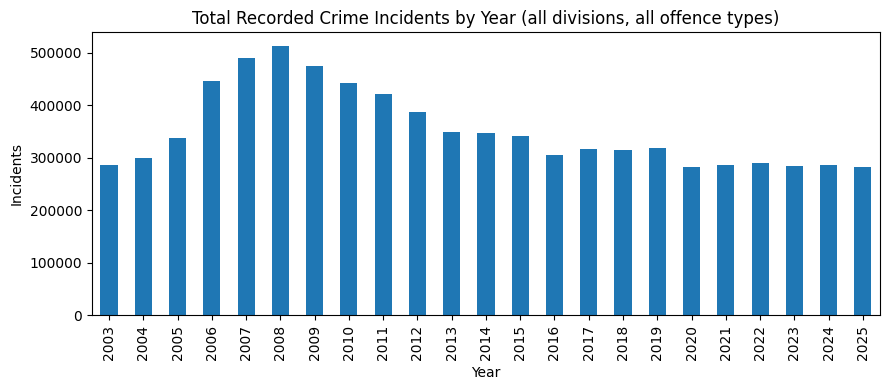

In [5]:
# Chart: Total Recorded Crime Incidents by Year
yearly_total = top_level.groupby("Year")["Incidents"].sum()

plt.figure(figsize=(9, 4))
yearly_total.plot(kind="bar")
plt.title("Total Recorded Crime Incidents by Year (all divisions, all offence types)")
plt.ylabel("Incidents")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

## Most common offence categories overall

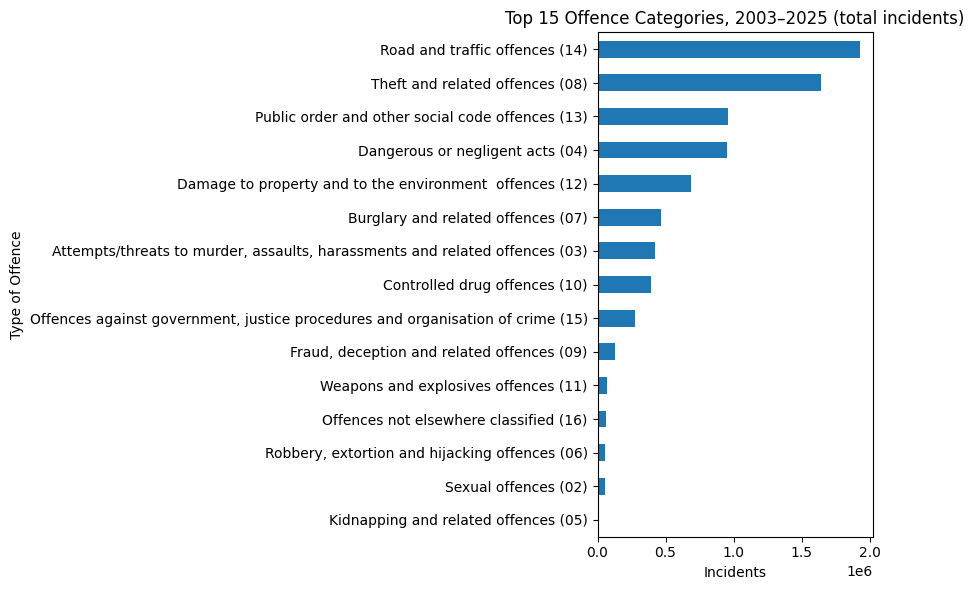

In [6]:
# Chart: Top 15 Offence Categories
by_offence = top_level.groupby("Type of Offence")["Incidents"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
by_offence.head(15).sort_values().plot(kind="barh")  # sort so biggest bar is on top
plt.title("Top 15 Offence Categories, 2003–2025 (total incidents)")
plt.xlabel("Incidents")
plt.tight_layout()
plt.show()

## Which Garda Division records the most crime?

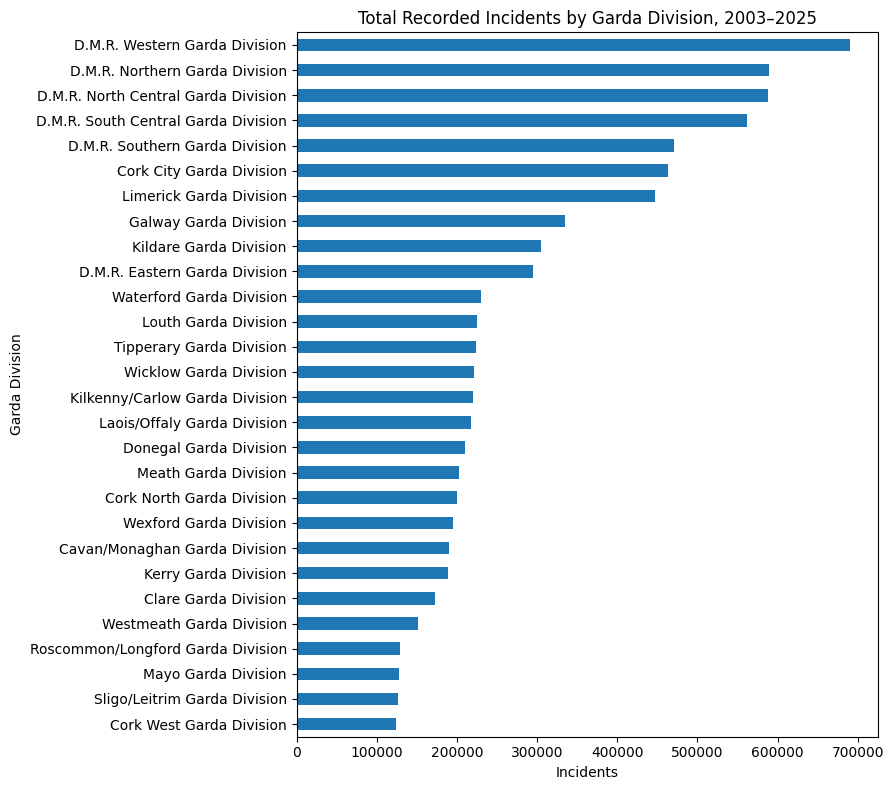

In [7]:
# Chart: Total Recorded Incidents by Garda Division
by_division = top_level.groupby("Garda Division")["Incidents"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 8))
by_division.sort_values().plot(kind="barh")  # sort so biggest bar is on top
plt.title("Total Recorded Incidents by Garda Division, 2003–2025")
plt.xlabel("Incidents")
plt.tight_layout()
plt.show()

Same numbers as a plain ranked table — easier to look up a specific county (e.g. Kerry, Cork) than reading bar-chart labels.

In [8]:
# same division totals as above, but as a plain numbered list (easier to search by name)
for i, (division, incidents) in enumerate(by_division.items(), start=1):
    print(f"{i:>2}. {incidents:>10,.0f}  {division}")

 1.    690,321  D.M.R. Western Garda Division
 2.    589,047  D.M.R. Northern Garda Division
 3.    588,605  D.M.R. North Central Garda Division
 4.    561,370  D.M.R. South Central Garda Division
 5.    470,970  D.M.R. Southern Garda Division
 6.    463,624  Cork City Garda Division
 7.    446,876  Limerick Garda Division
 8.    335,336  Galway Garda Division
 9.    304,490  Kildare Garda Division
10.    295,109  D.M.R. Eastern Garda Division
11.    230,267  Waterford Garda Division
12.    224,729  Louth Garda Division
13.    224,063  Tipperary Garda Division
14.    220,963  Wicklow Garda Division
15.    220,193  Kilkenny/Carlow Garda Division
16.    217,237  Laois/Offaly Garda Division
17.    210,128  Donegal Garda Division
18.    202,607  Meath Garda Division
19.    199,591  Cork North Garda Division
20.    195,717  Wexford Garda Division
21.    189,627  Cavan/Monaghan Garda Division
22.    188,489  Kerry Garda Division
23.    172,121  Clare Garda Division
24.    151,049  Westmeath 

## Trend for a specific offence category

Change `offence_of_interest` below to explore a different category from the list printed earlier (e.g. `"Burglary and related offences (07)"`, `"Theft and related offences (08)"`).

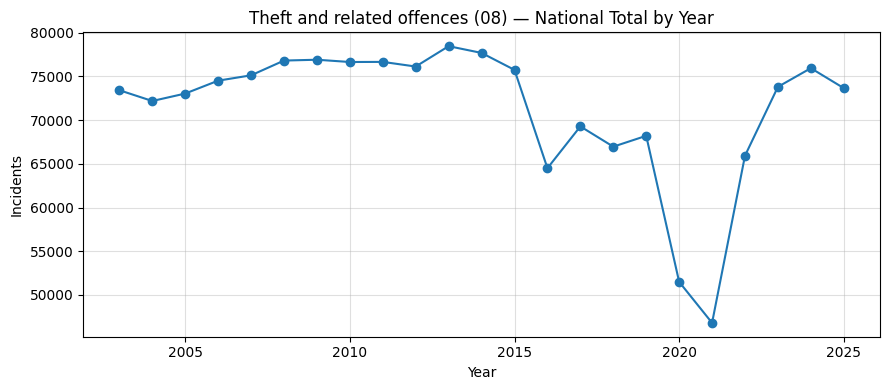

In [9]:
# Chart: Yearly Trend for One Offence Category
# change this to any category name from the list printed further up
offence_of_interest = "Theft and related offences (08)"

trend = (
    top_level[top_level["Type of Offence"] == offence_of_interest]
    .groupby("Year")["Incidents"]
    .sum()
)

plt.figure(figsize=(9, 4))
trend.plot(marker="o")
plt.title(f"{offence_of_interest} — National Total by Year")
plt.ylabel("Incidents")
plt.xlabel("Year")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()